In [1]:
!pip install timm

In [2]:
import os
import numpy as np
import pandas as pd

from pathlib import Path
from PIL import Image

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import timm

In [3]:
BASE_DIR = Path(
    "/content/drive/MyDrive/AI Work/Thermal image Motor/IR-Motor-bmp"
)

In [4]:
rows = []

for class_dir in BASE_DIR.iterdir():

    if class_dir.is_dir():

        for img_path in class_dir.glob("*.bmp"):

            rows.append(
                [
                    str(img_path),
                    class_dir.name
                ]
            )

In [5]:
df = pd.DataFrame(
    rows,
    columns=[
        "image_path",
        "label"
    ]
)

print(df.shape)

df.head()

(369, 2)


,image_path,label
0,/content/drive/MyDrive/AI Work/Thermal image M...,Noload
1,/content/drive/MyDrive/AI Work/Thermal image M...,Noload
2,/content/drive/MyDrive/AI Work/Thermal image M...,Noload
3,/content/drive/MyDrive/AI Work/Thermal image M...,Noload
4,/content/drive/MyDrive/AI Work/Thermal image M...,Noload


In [6]:
df.label.value_counts()

,count
label,
A&C&B30,42
A&B50,38
A&C30,38
A30,37
A50,35
A10,34
A&C10,31
A&C&B10,31
Rotor-0,30


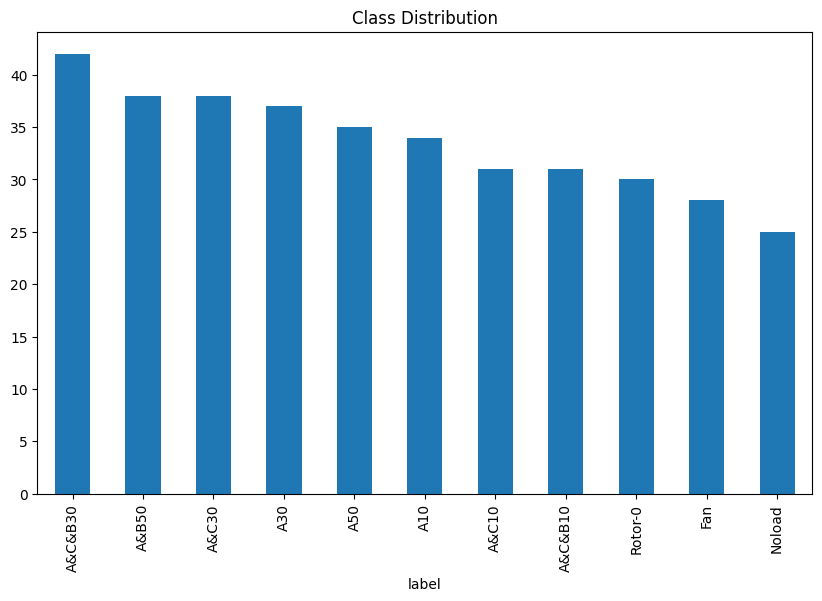

In [7]:
plt.figure(
    figsize=(10,6)
)

df.label.value_counts().plot(
    kind="bar"
)

plt.title(
    "Class Distribution"
)

plt.show()

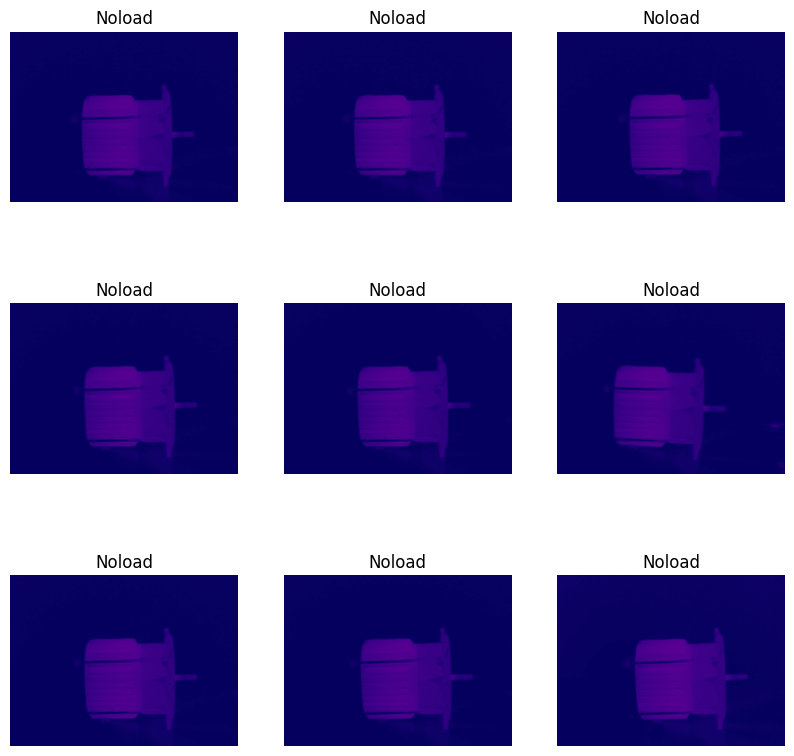

In [8]:
fig, axes = plt.subplots(
    3,
    3,
    figsize=(10,10)
)

for ax, idx in zip(
    axes.flatten(),
    range(9)
):

    img = Image.open(
        df.image_path.iloc[idx]
    )

    ax.imshow(img)

    ax.set_title(
        df.label.iloc[idx]
    )

    ax.axis("off")

plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
encoder = LabelEncoder()

df["label_id"] = encoder.fit_transform(
    df["label"]
)

df.head()

,image_path,label,label_id
0,/content/drive/MyDrive/AI Work/Thermal image M...,Noload,9
1,/content/drive/MyDrive/AI Work/Thermal image M...,Noload,9
2,/content/drive/MyDrive/AI Work/Thermal image M...,Noload,9
3,/content/drive/MyDrive/AI Work/Thermal image M...,Noload,9
4,/content/drive/MyDrive/AI Work/Thermal image M...,Noload,9


In [11]:
label_map = dict(
    zip(
        encoder.classes_,
        encoder.transform(
            encoder.classes_
        )
    )
)

label_map

{'A&B50': np.int64(0),
 'A&C&B10': np.int64(1),
 'A&C&B30': np.int64(2),
 'A&C10': np.int64(3),
 'A&C30': np.int64(4),
 'A10': np.int64(5),
 'A30': np.int64(6),
 'A50': np.int64(7),
 'Fan': np.int64(8),
 'Noload': np.int64(9),
 'Rotor-0': np.int64(10)}

In [12]:
import json

# Convert numpy int64 values to standard Python integers
serializable_label_map = {k: int(v) for k, v in label_map.items()}

with open(
    "label_map.json",
    "w"
) as f:

    json.dump(
        serializable_label_map,
        f,
        indent=4
    )

In [26]:
transform = transforms.Compose([
    transforms.Resize(
        (518,518)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [27]:
class ThermalDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        transform
    ):

        self.df = dataframe

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(
        self,
        idx
    ):

        img = Image.open(
            self.df.iloc[idx]["image_path"]
        )

        img = img.convert("RGB")

        img = self.transform(img)

        label = int(
            self.df.iloc[idx]["label_id"]
        )

        return img, label

In [28]:
dataset = ThermalDataset(
    df,
    transform
)

In [29]:
loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [30]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

device

device(type='cpu')

In [31]:
backbone = timm.create_model(
    "vit_base_patch14_dinov2",
    pretrained=True
)

In [32]:
backbone.reset_classifier(
    0
)

In [33]:
backbone = backbone.to(
    device
)

backbone.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=Fal

In [35]:
dummy = torch.randn(
    1,
    3,
    518,
    518
).to(device)

In [36]:
print(backbone.default_cfg)

{'url': 'https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth', 'hf_hub_id': 'timm/vit_base_patch14_dinov2.lvd142m', 'architecture': 'vit_base_patch14_dinov2', 'tag': 'lvd142m', 'custom_load': False, 'input_size': (3, 518, 518), 'fixed_input_size': True, 'interpolation': 'bicubic', 'crop_pct': 1.0, 'crop_mode': 'center', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'num_classes': 0, 'pool_size': None, 'first_conv': 'patch_embed.proj', 'classifier': 'head', 'license': 'apache-2.0'}


In [37]:
print(backbone.patch_embed.img_size)

(518, 518)


In [38]:
with torch.no_grad():
  emb = backbone(dummy)

print(
    emb.shape
)

torch.Size([1, 768])


In [39]:
all_embeddings = []

all_labels = []

In [ ]:
with torch.no_grad():

    for images, labels in loader:

        images = images.to(
            device
        )

        features = backbone(
            images
        )

        all_embeddings.append(
            features.cpu().numpy()
        )

        all_labels.append(
            labels.numpy()
        )

In [ ]:
embeddings = np.concatenate(
    all_embeddings,
    axis=0
)

labels = np.concatenate(
    all_labels,
    axis=0
)

In [ ]:
print(
    embeddings.shape
)

print(
    labels.shape
)

In [ ]:
np.save(
    "thermal_embeddings.npy",
    embeddings
)

In [ ]:
np.save(
    "thermal_labels.npy",
    labels
)

In [ ]:
df.to_csv(
    "thermal_metadata.csv",
    index=False
)

In [ ]:
!pip install umap-learn -q

In [ ]:
import umap

In [ ]:
reducer = umap.UMAP(
    random_state=42
)

In [ ]:
embedding_2d = reducer.fit_transform(
    embeddings
)

In [ ]:
plt.figure(
    figsize=(10,8)
)

scatter = plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=labels,
    cmap="tab20"
)

plt.colorbar(scatter)

plt.title(
    "Thermal Embedding Space"
)

plt.show()

In [ ]:
torch.save(
    backbone.state_dict(),
    "dinov2_thermal_encoder.pth"
)